# ForecastLab — EXP-014 Dashboard & Inference

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-002 |
| **Eksperimen** | EXP-014 |
| **Dataset** | featured_data.csv |
| **Author** | GAKUSEI Najib |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

target = 'PowerConsumption_Zone1'
exclude = ['Datetime', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
feature_cols = [c for c in df.columns if c not in exclude and c != target]

train = df[df['Datetime'] < '2017-07-01']
test  = df[df['Datetime'] >= '2017-07-01']
X_train, y_train = train[feature_cols].fillna(0), train[target]
X_test, y_test = test[feature_cols].fillna(0), test[target]
print(f'Data loaded: train={len(train)}, test={len(test)}')

Data loaded: train=25920, test=26352


In [2]:
MODEL_PATH = '../models/best_model.pkl'
if os.path.exists(MODEL_PATH):
    import joblib
    model = joblib.load(MODEL_PATH)
    print('Model loaded from best_model.pkl')
else:
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    print('Model trained: Random Forest (fallback)')

y_pred = model.predict(X_test)

Model loaded from best_model.pkl


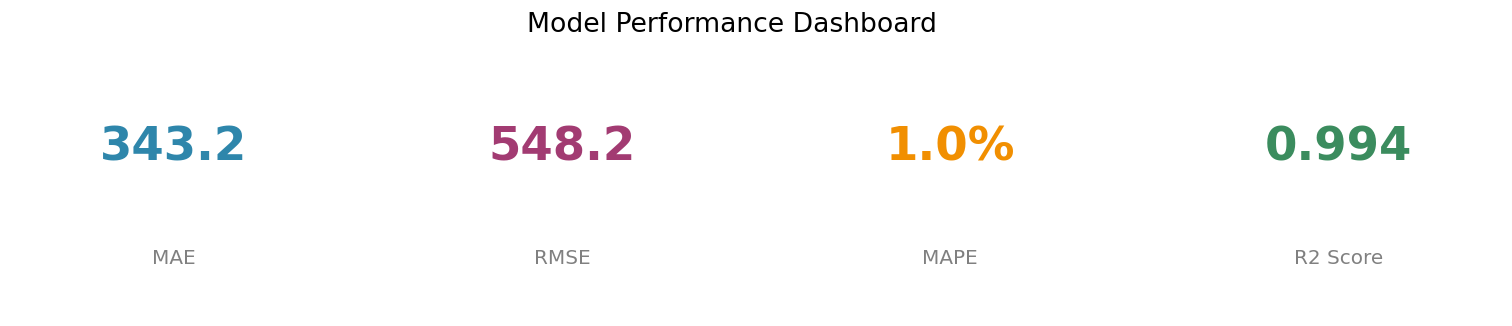

In [3]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
metrics = [('MAE', f'{mae:.1f}', '#2e86ab'), ('RMSE', f'{rmse:.1f}', '#a23b72'), ('MAPE', f'{mape:.1f}%', '#f18f01'), ('R2 Score', f'{r2:.3f}', '#3b8c5e')]
for ax, (title, value, color) in zip(axes, metrics):
    ax.text(0.5, 0.6, value, fontsize=28, fontweight='bold', ha='center', va='center', color=color)
    ax.text(0.5, 0.2, title, fontsize=12, ha='center', va='center', color='gray')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
plt.suptitle('Model Performance Dashboard', fontsize=16, y=0.95)
plt.savefig('../data/dash_01_kpi.png', bbox_inches='tight', dpi=120)
plt.show()

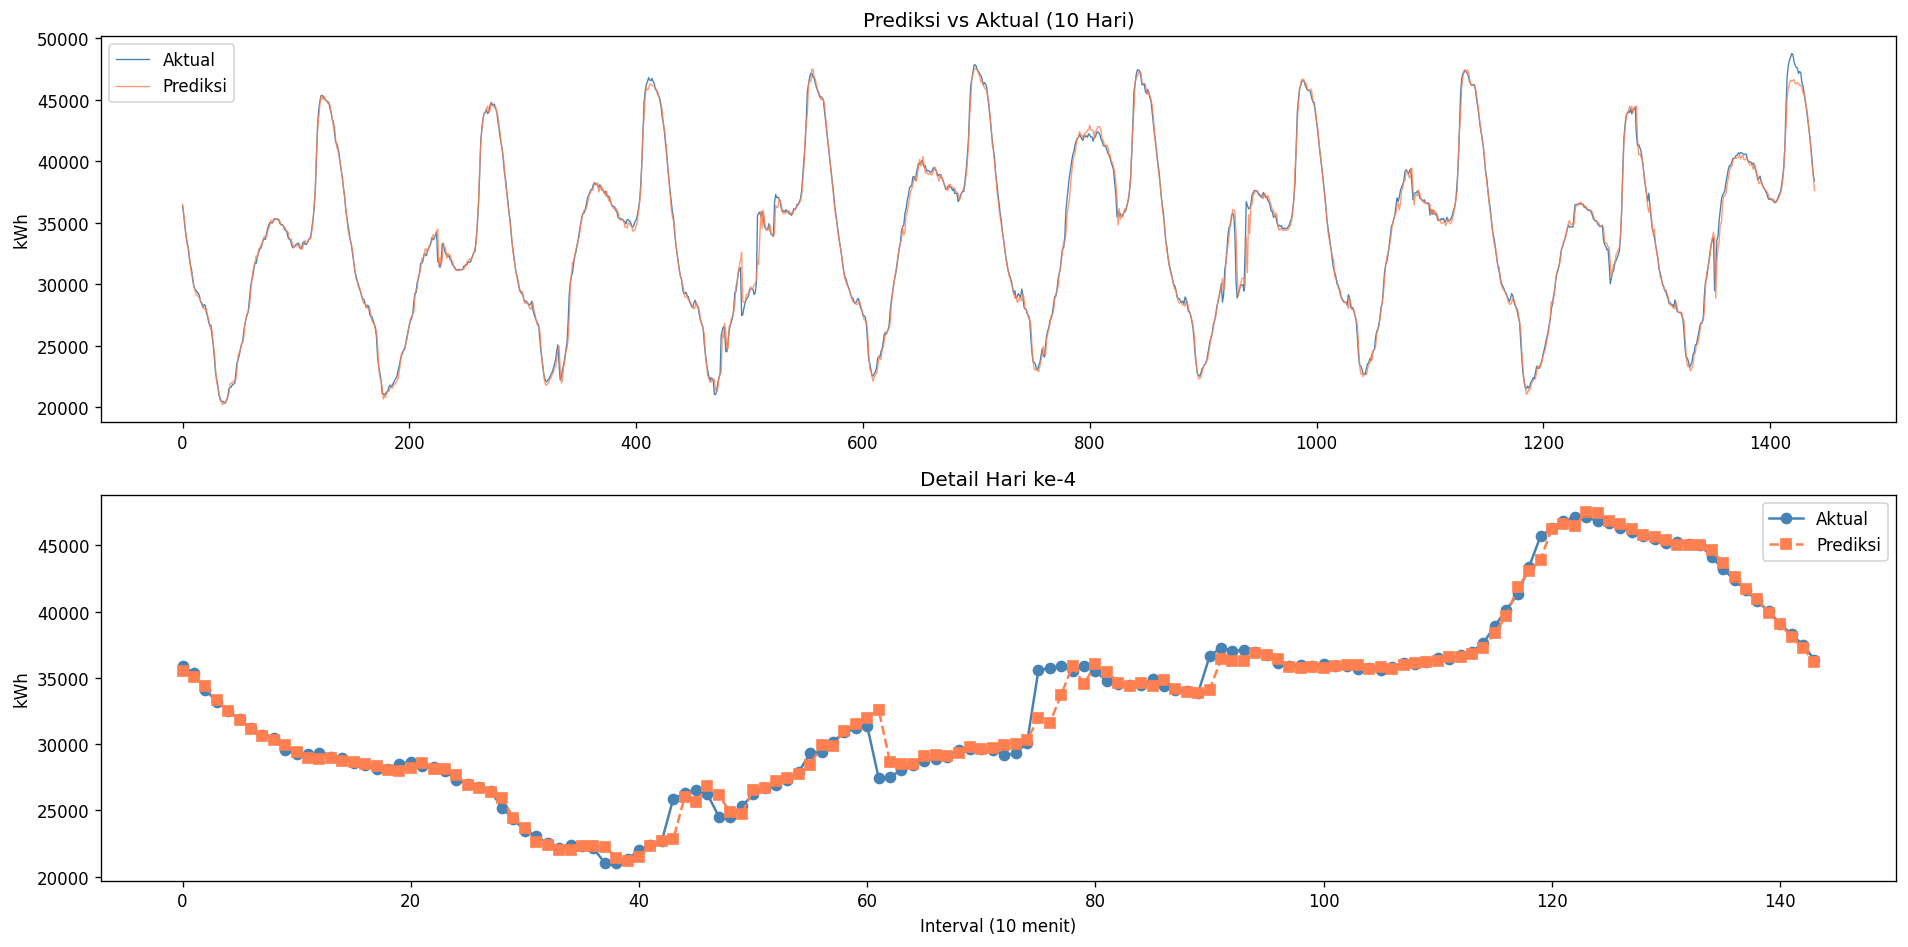

In [4]:
n_show = 1440
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(range(n_show), y_test.values[:n_show], label='Aktual', color='steelblue', linewidth=0.8)
axes[0].plot(range(n_show), y_pred[:n_show], label='Prediksi', color='coral', alpha=0.8, linewidth=0.8)
axes[0].set_title('Prediksi vs Aktual (10 Hari)')
axes[0].legend()
axes[0].set_ylabel('kWh')
n_day = 144
start = 144 * 3
axes[1].plot(range(n_day), y_test.values[start:start+n_day], 'o-', label='Aktual', color='steelblue')
axes[1].plot(range(n_day), y_pred[start:start+n_day], 's--', label='Prediksi', color='coral')
axes[1].set_title('Detail Hari ke-4')
axes[1].legend()
axes[1].set_xlabel('Interval (10 menit)')
axes[1].set_ylabel('kWh')
plt.tight_layout()
plt.savefig('../data/dash_02_prediction.png', bbox_inches='tight', dpi=120)
plt.show()

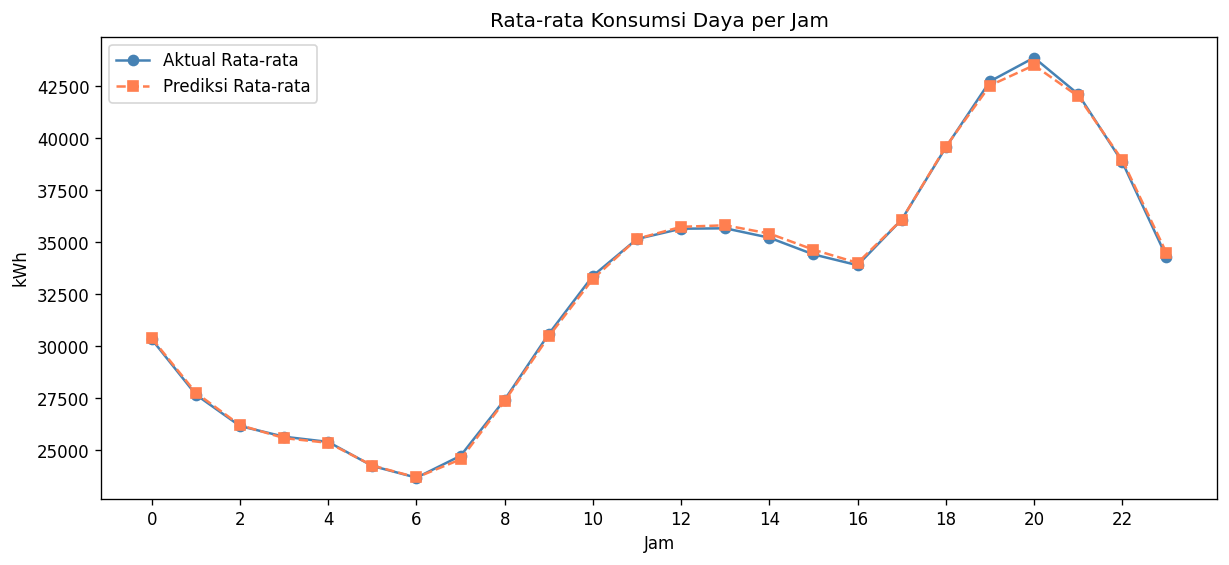

In [5]:
hourly_actual = test.groupby('Hour')[target].mean()
hourly_pred = pd.DataFrame({'Hour': test['Hour'].values, 'pred': y_pred}).groupby('Hour')['pred'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_actual.index, hourly_actual.values, 'o-', label='Aktual Rata-rata', color='steelblue')
ax.plot(hourly_pred.index, hourly_pred.values, 's--', label='Prediksi Rata-rata', color='coral')
ax.set_title('Rata-rata Konsumsi Daya per Jam')
ax.set_xlabel('Jam'); ax.set_ylabel('kWh')
ax.set_xticks(range(0, 24, 2)); ax.legend()
plt.savefig('../data/dash_03_hourly_pattern.png', bbox_inches='tight', dpi=120)
plt.show()

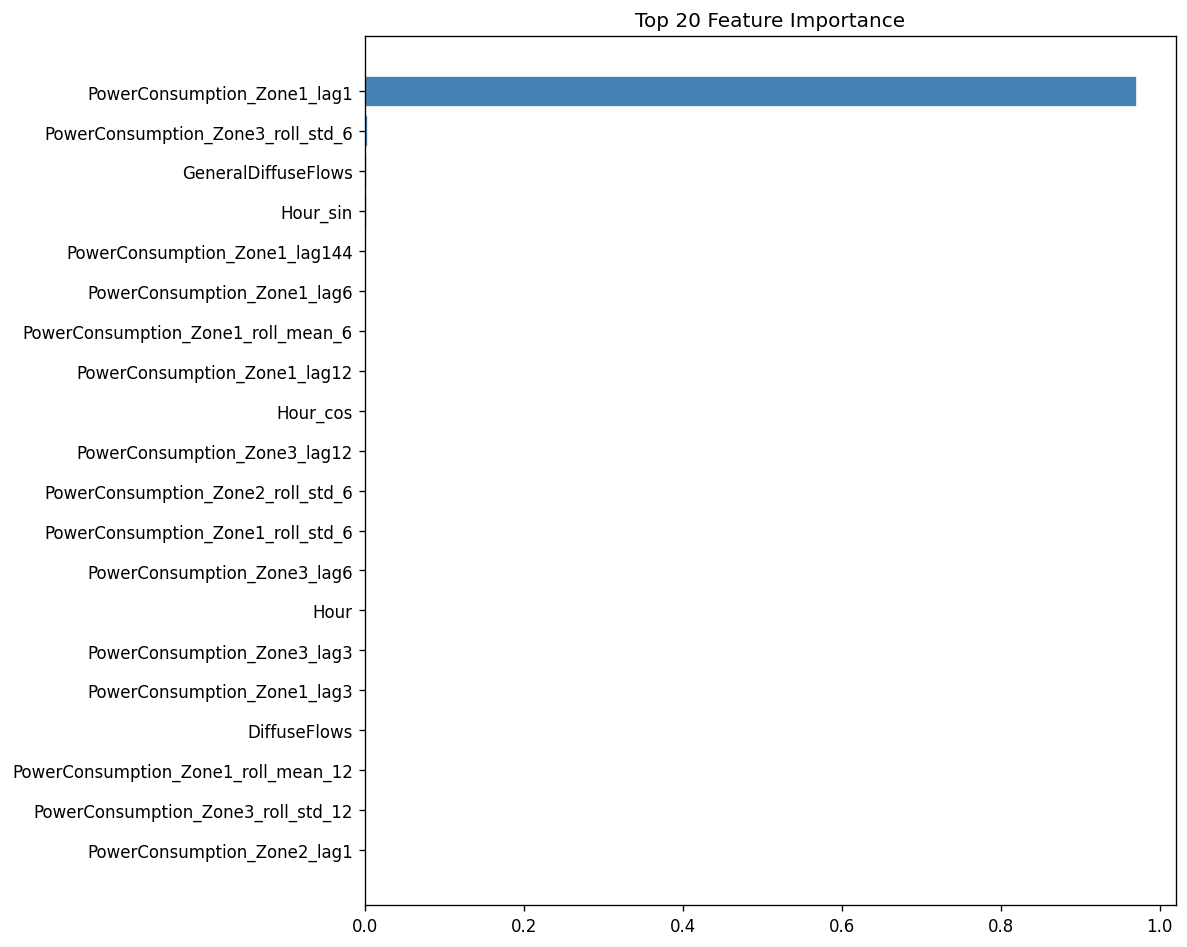

In [6]:
if hasattr(model, 'feature_importances_'):
    importances = pd.DataFrame({'Feature': feature_cols, 'Importance': model.feature_importances_})
    importances = importances.sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(importances['Feature'][-20:], importances['Importance'][-20:], color='steelblue', edgecolor='white')
    ax.set_title('Top 20 Feature Importance')
    plt.tight_layout()
    plt.savefig('../data/dash_04_importance.png', bbox_inches='tight', dpi=120)
    plt.show()

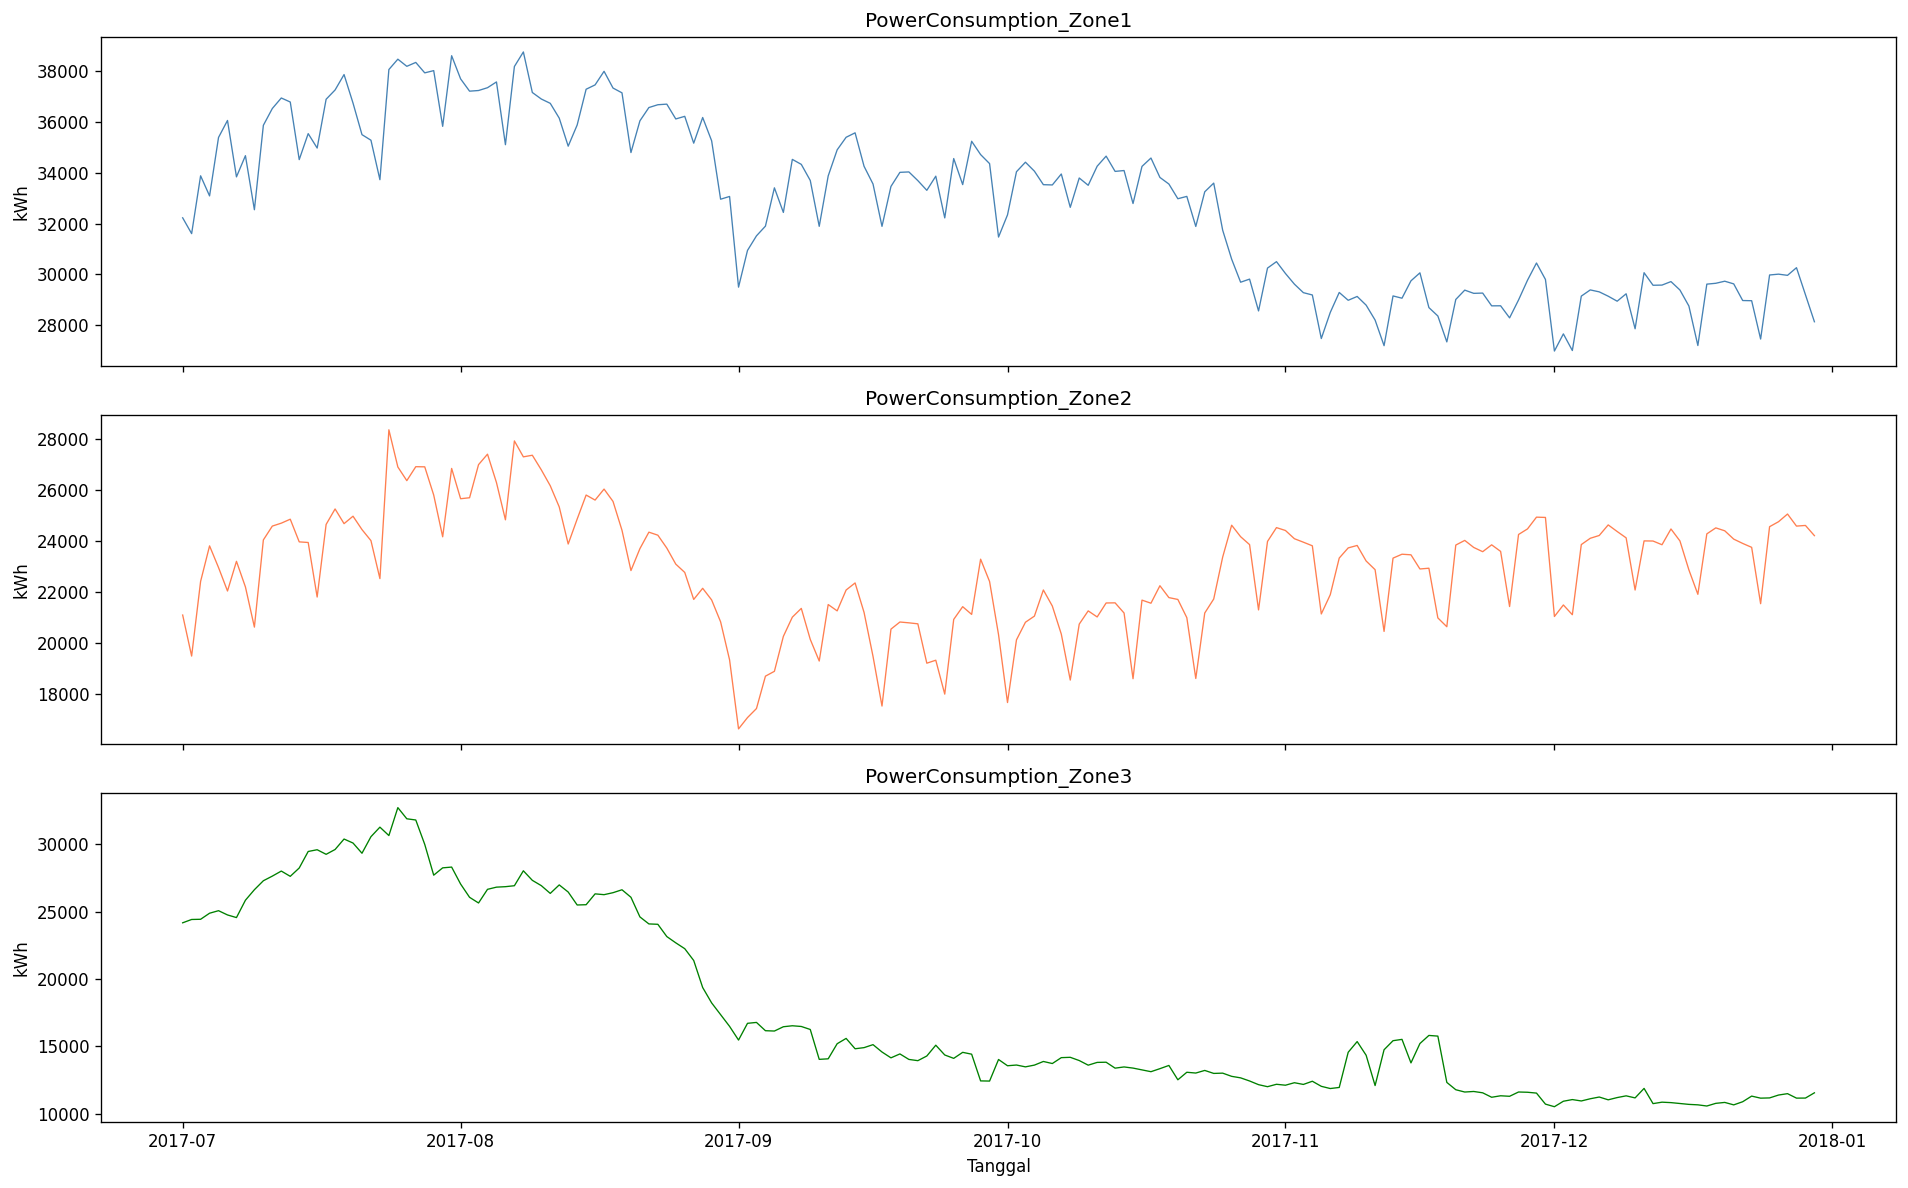

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
daily_test = test.groupby(test['Datetime'].dt.date).mean()
for i, col in enumerate(['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']):
    axes[i].plot(daily_test.index, daily_test[col], color=['steelblue', 'coral', 'green'][i], linewidth=0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel('kWh')
plt.xlabel('Tanggal')
plt.tight_layout()
plt.savefig('../data/dash_05_timeseries.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Kesimpulan

Dashboard menampilkan:
- KPI Cards: MAE, RMSE, MAPE, R2
- Prediction Plot: Aktual vs Prediksi
- Hourly Pattern: Pola konsumsi per jam
- Feature Importance: Fitur paling berpengaruh
- Time Series: Historis 3 zona

**Next: EXP-015 Final Documentation**